## Homework

> Note: sometimes your answer doesn't match one of 
> the options exactly. That's fine. 
> Select the option that's closest to your solution.


In this homework, we will use the lead scoring dataset Bank Marketing dataset. Download it from [here](https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv).


In this dataset our desired target for classification task will be `converted` variable - has the client signed up to the platform or not. 

### Data preparation

* Check if the missing values are presented in the features.
* If there are missing values:
    * For caterogiral features, replace them with 'NA'
    * For numerical features, replace with with 0.0 


Split the data into 3 parts: train/validation/test with 60%/20%/20% distribution. Use `train_test_split` function for that with `random_state=1`

In [391]:
# !wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv

In [392]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [393]:
df = pd.read_csv('../data/course_lead_scoring.csv')

In [394]:
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [395]:
df.dtypes

lead_source                  object
industry                     object
number_of_courses_viewed      int64
annual_income               float64
employment_status            object
location                     object
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [396]:
df.isnull().sum()

lead_source                 128
industry                    134
number_of_courses_viewed      0
annual_income               181
employment_status           100
location                     63
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [397]:
# numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
# categorical_columns = df.select_dtypes(include=['object']).columns
numerical = ['number_of_courses_viewed', 'annual_income', 'interaction_count', 'lead_score']
categorical = ['lead_source', 'industry', 'employment_status', 'location']
target = ['converted']

for col in numerical:
    df[col] = df[col].fillna(0.0)
    
for col in categorical:
    df[col] = df[col].fillna('NA')

In [398]:
df.isnull().sum()

lead_source                 0
industry                    0
number_of_courses_viewed    0
annual_income               0
employment_status           0
location                    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

In [399]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values

del df_train['converted']
del df_val['converted']
del df_test['converted']

print('Training set size:', len(df_train), f"{len(df_train) / (len(df_train) + len(df_val) + len(df_test))}")
print('Validation set size:', len(df_val), f"{len(df_val) / (len(df_train) + len(df_val) + len(df_test))}")
print('Test set size:', len(df_test), f"{len(df_test) / (len(df_train) + len(df_val) + len(df_test))}")

Training set size: 876 0.5991792065663475
Validation set size: 293 0.20041039671682626
Test set size: 293 0.20041039671682626


### Question 1: ROC AUC feature importance

ROC AUC could also be used to evaluate feature importance of numerical variables. 

Let's do that

* For each numerical variable, use it as score (aka prediction) and compute the AUC with the `y` variable as ground truth.
* Use the training dataset for that


If your AUC is < 0.5, invert this variable by putting "-" in front

(e.g. `-df_train['balance']`)

AUC can go below 0.5 if the variable is negatively correlated with the target variable. You can change the direction of the correlation by negating this variable - then negative correlation becomes positive.

Which numerical variable (among the following 4) has the highest AUC?

- `lead_score`
- **`number_of_courses_viewed`**
- `interaction_count`
- `annual_income`

In [400]:
from sklearn.metrics import roc_auc_score

In [401]:
variables = ['lead_score', 'number_of_courses_viewed', 'interaction_count', 'annual_income']
auc_scores = {}

for var in variables:
    score = df_train[var]
    
    auc = roc_auc_score(y_train, score)
    
    if auc < 0.5:
        auc = roc_auc_score(y_train, -score)
        print(f"{var}: {auc:.4f} (inverted)")
    else:
        print(f"{var}: {auc:.4f}")
        
    auc_scores[var] = auc

best_var = max(auc_scores.items(), key=lambda x: x[1])
print(f"\nHighest AUC: {best_var[0]} ({best_var[1]:.4f})")

lead_score: 0.6145
number_of_courses_viewed: 0.7636
interaction_count: 0.7383
annual_income: 0.5520

Highest AUC: number_of_courses_viewed (0.7636)


### Question 2: Training the model

Apply one-hot-encoding using `DictVectorizer` and train the logistic regression with these parameters:

```python
LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
```

What's the AUC of this model on the validation dataset? (round to 3 digits)

- 0.32
- 0.52
- **0.72**
- 0.92

In [402]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

In [403]:
def train(df_train, y_train, C=1.0):
    dicts = df_train[categorical + numerical].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
    model.fit(X_train, y_train)

    return dv, model

def predict(df, dv, model):
    dicts = df[categorical + numerical].to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

In [404]:
dv, model = train(df_train, y_train, C=1.0)

In [405]:
y_val_pred = predict(df_val, dv, model)
y_val_pred

array([0.57539503, 0.47060768, 0.61901236, 0.6143892 , 0.61741031,
       0.67496748, 0.8465351 , 0.38205015, 0.55735358, 0.91246751,
       0.77549359, 0.66110422, 0.91574386, 0.38389183, 0.88197523,
       0.89511778, 0.65336369, 0.53077648, 0.73106703, 0.70418456,
       0.78080321, 0.51381844, 0.88869813, 0.72195815, 0.91633086,
       0.53483932, 0.50123084, 0.84175873, 0.48497478, 0.60635462,
       0.63002389, 0.50197705, 0.54916064, 0.91861628, 0.6902664 ,
       0.65666092, 0.84766044, 0.79947504, 0.47461069, 0.63286015,
       0.82887379, 0.4355907 , 0.45453631, 0.58816791, 0.64477414,
       0.73619001, 0.53893926, 0.71596382, 0.74170518, 0.86747808,
       0.77685777, 0.75943833, 0.84663023, 0.67334212, 0.78059001,
       0.68835976, 0.63561826, 0.56955796, 0.6699862 , 0.75372267,
       0.33388224, 0.6815564 , 0.35336532, 0.7745121 , 0.51403962,
       0.2620089 , 0.66844162, 0.41567479, 0.49375719, 0.54251895,
       0.85677057, 0.39794252, 0.46701359, 0.85106564, 0.77222

In [406]:
auc_score = roc_auc_score(y_val, y_val_pred)
print(f'Validation AUC: {auc_score}')

Validation AUC: 0.8171316268814112


### Question 3: Precision and Recall

Now let's compute precision and recall for our model.

* Evaluate the model on all thresholds from 0.0 to 1.0 with step 0.01
* For each threshold, compute precision and recall
* Plot them

At which threshold precision and recall curves intersect?

* 0.145
* 0.345
* **0.545**
* 0.745

In [407]:
from sklearn.metrics import precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np

In [408]:
thresholds = np.arange(0.0, 1.01, 0.01)
precisions = []
recalls = []

for t in thresholds:
    y_pred = (y_val_pred >= t).astype(int)
    p = precision_score(y_val, y_pred, zero_division=0)
    r = recall_score(y_val, y_pred, zero_division=0)
    precisions.append(p)
    recalls.append(r)

precisions = np.array(precisions)
recalls = np.array(recalls)

mask = (precisions > 0.1) & (recalls > 0.1)
valid_thresholds = thresholds[mask]
valid_precisions = precisions[mask]
valid_recalls = recalls[mask]

intersection_idx = np.argmin(np.abs(valid_precisions - valid_recalls))
intersection_threshold = valid_thresholds[intersection_idx]
intersection_value = valid_precisions[intersection_idx]


In [409]:
print(f"Threshold (x) = {intersection_threshold:.3f}")
print(f"Precision = Recall (y) = {intersection_value:.3f}")
print(f"Point = ({intersection_threshold:.3f}, {intersection_value:.3f})")

Threshold (x) = 0.640
Precision = Recall (y) = 0.779
Point = (0.640, 0.779)


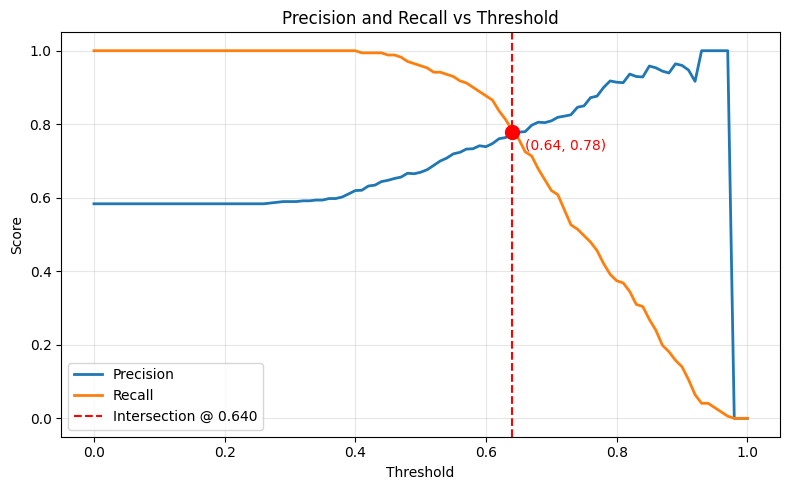

In [410]:
plt.figure(figsize=(8,5))
plt.plot(thresholds, precisions, label='Precision', linewidth=2)
plt.plot(thresholds, recalls, label='Recall', linewidth=2)

plt.axvline(intersection_threshold, color='red', linestyle='--', label=f'Intersection @ {intersection_threshold:.3f}')
plt.scatter(intersection_threshold, intersection_value, color='red', s=100, zorder=5)
plt.text(intersection_threshold + 0.02, intersection_value - 0.05,
         f"({intersection_threshold:.2f}, {intersection_value:.2f})",
         color='red', fontsize=10)

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Threshold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Question 4: F1 score

Precision and recall are conflicting - when one grows, the other goes down. That's why they are often combined into the F1 score - a metrics that takes into account both

This is the formula for computing F1:

$$F_1 = 2 \cdot \cfrac{P \cdot R}{P + R}$$

Where $P$ is precision and $R$ is recall.

Let's compute F1 for all thresholds from 0.0 to 1.0 with increment 0.01

At which threshold F1 is maximal?

- 0.14
- 0.34
- **0.54**
- 0.74

In [411]:
from sklearn.metrics import f1_score

In [412]:
thresholds = np.arange(0, 1.01, 0.01)

f1_scores = []

for threshold in thresholds:
    y_pred = (y_val_pred >= threshold).astype(int)
    
    f1 = f1_score(y_val, y_pred)
    f1_scores.append(f1)

f1_scores = np.array(f1_scores)

max_f1_idx = np.argmax(f1_scores)
max_f1_threshold = thresholds[max_f1_idx]
max_f1_score = f1_scores[max_f1_idx]

In [413]:
print(f"Maximum F1 score: {max_f1_score:.3f}")
print(f"Threshold (x) = {max_f1_threshold:.3f}")
print(f"Point = ({max_f1_threshold:.3f}, {max_f1_score:.3f})")

Maximum F1 score: 0.812
Threshold (x) = 0.570
Point = (0.570, 0.812)


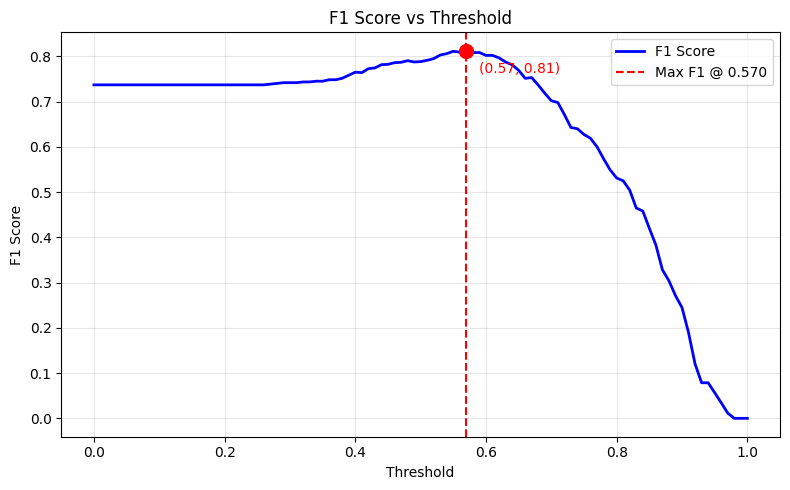

In [414]:
plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores, label='F1 Score', linewidth=2, color='blue')

plt.axvline(max_f1_threshold, color='red', linestyle='--', label=f'Max F1 @ {max_f1_threshold:.3f}')
plt.scatter(max_f1_threshold, max_f1_score, color='red', s=100, zorder=5)
plt.text(max_f1_threshold + 0.02, max_f1_score - 0.05,
         f"({max_f1_threshold:.2f}, {max_f1_score:.2f})",
         color='red', fontsize=10)
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Threshold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Question 5: 5-Fold CV


Use the `KFold` class from Scikit-Learn to evaluate our model on 5 different folds:

```
KFold(n_splits=5, shuffle=True, random_state=1)
```

* Iterate over different folds of `df_full_train`
* Split the data into train and validation
* Train the model on train with these parameters: `LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)`
* Use AUC to evaluate the model on validation

How large is standard deviation of the scores across different folds?

- 0.0001
- 0.006
- **0.06**
- 0.36

In [417]:
from sklearn.model_selection import KFold

In [418]:
def df_to_dict(df):
    return df.to_dict(orient='records')

kf = KFold(n_splits=5, shuffle=True, random_state=1)
scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(df_full_train), 1):
    # Split the folds
    df_train_fold = df_full_train.iloc[train_idx]
    df_val_fold = df_full_train.iloc[val_idx]
    
    # Separate target variable
    y_train_fold = df_train_fold.converted.values
    y_val_fold = df_val_fold.converted.values
    
    # Remove target from features
    df_train_fold = df_train_fold.drop('converted', axis=1)
    df_val_fold = df_val_fold.drop('converted', axis=1)
    
    # One-hot encoding
    dv = DictVectorizer(sparse=False)
    X_train_fold = dv.fit_transform(df_to_dict(df_train_fold))
    X_val_fold = dv.transform(df_to_dict(df_val_fold))
    
    # Train Logistic Regression
    model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
    model.fit(X_train_fold, y_train_fold)
    
    # Predict and evaluate AUC
    y_pred_fold = model.predict_proba(X_val_fold)[:, 1]
    auc = roc_auc_score(y_val_fold, y_pred_fold)
    scores.append(auc)
    
    print(f"Fold {fold}: AUC = {auc:.3f}")

# Calculate mean and std
mean_auc = np.mean(scores)
std_auc = np.std(scores)

print("\n==============================")
print(f"Mean AUC: {mean_auc:.3f}")
print(f"Standard deviation: {std_auc:.6f}")
print("==============================")

Fold 1: AUC = 0.806
Fold 2: AUC = 0.871
Fold 3: AUC = 0.775
Fold 4: AUC = 0.802
Fold 5: AUC = 0.856

Mean AUC: 0.822
Standard deviation: 0.035807


### Question 6: Hyperparameter Tuning

Now let's use 5-Fold cross-validation to find the best parameter `C`

* Iterate over the following `C` values: `[0.000001, 0.001, 1]`
* Initialize `KFold` with the same parameters as previously
* Use these parameters for the model: `LogisticRegression(solver='liblinear', C=C, max_iter=1000)`
* Compute the mean score as well as the std (round the mean and std to 3 decimal digits)

Which `C` leads to the best mean score?

- 0.000001
- **0.001**
- 1

If you have ties, select the score with the lowest std. If you still have ties, select the smallest `C`.

In [419]:
c_values = [0.000001, 0.001, 1]
kf = KFold(n_splits=5, shuffle=True, random_state=1)
results = {}

for C in c_values:
    scores = []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(df_full_train), 1):
        # Split folds
        df_train_fold = df_full_train.iloc[train_idx]
        df_val_fold = df_full_train.iloc[val_idx]
        
        y_train_fold = df_train_fold.converted.values
        y_val_fold = df_val_fold.converted.values
        
        df_train_fold = df_train_fold.drop('converted', axis=1)
        df_val_fold = df_val_fold.drop('converted', axis=1)
        
        # One-hot encode with DictVectorizer
        dv = DictVectorizer(sparse=False)
        X_train_fold = dv.fit_transform(df_to_dict(df_train_fold))
        X_val_fold = dv.transform(df_to_dict(df_val_fold))
        
        # Train Logistic Regression
        model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
        model.fit(X_train_fold, y_train_fold)
        
        # Predict and evaluate AUC
        y_pred_fold = model.predict_proba(X_val_fold)[:, 1]
        auc = roc_auc_score(y_val_fold, y_pred_fold)
        scores.append(auc)
    
    mean_auc = np.mean(scores)
    std_auc = np.std(scores)
    results[C] = {'mean': round(mean_auc, 3), 'std': round(std_auc, 3)}
    
    print(f"C={C}: mean AUC={mean_auc:.3f}, std={std_auc:.3f}")

best_C = sorted(results.items(), key=lambda x: (-x[1]['mean'], x[1]['std'], x[0]))[0]

print("\n==============================")
print(f"Best C value: {best_C[0]}")
print(f"Mean AUC: {best_C[1]['mean']:.3f} ± {best_C[1]['std']:.3f}")
print("==============================")

C=1e-06: mean AUC=0.560, std=0.024
C=0.001: mean AUC=0.867, std=0.029
C=1: mean AUC=0.822, std=0.036

Best C value: 0.001
Mean AUC: 0.867 ± 0.029
